<a href="https://colab.research.google.com/github/riyu658/olist-ecommerce-analytics/blob/main/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
# Importing data

data_path = '/content/drive/MyDrive/olist/'

files = {
    'orders': 'olist_orders_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

data = {name: pd.read_csv(data_path + f) for name, f in files.items()}

# Convert date columns to datetime objects for the 'orders' dataframe
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    data['orders'][col] = pd.to_datetime(data['orders'][col])

##**1. Shape & Sample Row**

In [ ]:
# Overview Table

summary = pd.DataFrame({
    'table': list(data.keys()),
    'rows': [df.shape[0] for df in data.values()],
    'columns': [df.shape[1] for df in data.values()],
    'memory_mb': [round(df.memory_usage(deep=True).sum() / 1e6, 1) for df in data.values()],
})
summary.sort_values('rows', ascending=False, inplace=True)
summary.reset_index(drop=True, inplace=True)
summary

,table,rows,columns,memory_mb
0,geolocation,1000163,5,135.70
1,order_items,112650,7,37.70
2,order_payments,103886,5,17.00
3,orders,99441,8,25.90
4,customers,99441,5,27.90
5,order_reviews,99224,7,41.00
6,products,32951,9,6.60
7,sellers,3095,4,0.60
8,category_translation,71,2,0.00


In [ ]:
# Overview for each table

for name, df in data.items():
    print(f"\n{'='*70}\n📄 {name.upper()}  |  {df.shape[0]:,} rows × {df.shape[1]} cols\n{'='*70}")
    display(df.head(3))


📄 ORDERS  |  99,441 rows × 8 cols


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04



📄 CUSTOMERS  |  99,441 rows × 5 cols


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



📄 ORDER_ITEMS  |  112,650 rows × 7 cols


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



📄 GEOLOCATION  |  1,000,163 rows × 5 cols


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP



📄 CATEGORY_TRANSLATION  |  71 rows × 2 cols


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


##**2. Data Types & Schema**

In [ ]:
# Column Dtypes

for name, df in data.items():
    print(f"\n--- {name} ---")
    print(df.dtypes)


--- orders ---
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

--- customers ---
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

--- order_items ---
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

--- order_payments ---
order_id                 object
payment_sequential        int64
payment_type             object
paymen

##**3. Missing Values**

In [ ]:
def missing_report(df, name):
    miss = pd.DataFrame({
        'column': df.columns,
        'missing_count': df.isnull().sum().values,
        'missing_pct': (df.isnull().mean().values * 100).round(2)
    })
    miss = miss[miss['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    if miss.empty:
        print(f"✅ {name}: no missing values")
    else:
        print(f"⚠️  {name}:")
        display(miss)

for name, df in data.items():
    missing_report(df, name)

⚠️  orders:


,column,missing_count,missing_pct
6,order_delivered_customer_date,2965,2.98
5,order_delivered_carrier_date,1783,1.79
4,order_approved_at,160,0.16


✅ customers: no missing values
✅ order_items: no missing values
✅ order_payments: no missing values
⚠️  order_reviews:


,column,missing_count,missing_pct
3,review_comment_title,87656,88.34
4,review_comment_message,58247,58.70


⚠️  products:


,column,missing_count,missing_pct
1,product_category_name,610,1.85
2,product_name_lenght,610,1.85
3,product_description_lenght,610,1.85
4,product_photos_qty,610,1.85
5,product_weight_g,2,0.01
6,product_length_cm,2,0.01
7,product_height_cm,2,0.01
8,product_width_cm,2,0.01


✅ sellers: no missing values
✅ geolocation: no missing values
✅ category_translation: no missing values


##**4. Duplicates**

In [ ]:
# Important for "order_items" and "geolocation"

In [ ]:
# Duplicate Check

for name, df in data.items():
  dup = df.duplicated().sum()
  pct = dup / len(df) * 100
  print(f"{'⚠️' if pct > 5 else '✅'} {name:20s} duplicates: {dup:,} ({pct:.2f}%)")

✅ orders               duplicates: 0 (0.00%)
✅ customers            duplicates: 0 (0.00%)
✅ order_items          duplicates: 0 (0.00%)
✅ order_payments       duplicates: 0 (0.00%)
✅ order_reviews        duplicates: 0 (0.00%)
✅ products             duplicates: 0 (0.00%)
✅ sellers              duplicates: 0 (0.00%)
⚠️ geolocation          duplicates: 261,831 (26.18%)
✅ category_translation duplicates: 0 (0.00%)


##**5. Table Relationships - Join**

In [ ]:
# The dataset is relational. "order_id" is the spine connecting most tables.

In [ ]:
# Join key verification

# Do order_ids in order_items exist in orders?
print("order_items ⊄ orders:", len(set(data['order_items']['order_id']) - set(data['orders']['order_id'])))
print("reviews ⊄ orders:  ", len(set(data['order_reviews']['order_id']) - set(data['orders']['order_id'])))
print("payments ⊄ orders: ", len(set(data['order_payments']['order_id']) - set(data['orders']['order_id'])))
print()

order_items ⊄ orders: 0
reviews ⊄ orders:   0
payments ⊄ orders:  0



In [ ]:
# Order granularity check
print("Unique orders in 'orders':        ", data['orders']['order_id'].nunique())
print("Unique order_id+item in items:    ", data['order_items'].groupby(['order_id', 'order_item_id']).ngroups)
print("Review rows per order (max):      ", data['order_reviews'].groupby('order_id').size().max())
print("Payment rows per order (max):     ", data['order_payments'].groupby('order_id').size().max())

Unique orders in 'orders':         99441
Unique order_id+item in items:     112650
Review rows per order (max):       3
Payment rows per order (max):      29


##**6. Key Column Distribution (Quick Sanity Check)**

In [ ]:
# Order Status & Date Range

print("Order status counts:")
print(data['orders']['order_status'].value_counts())

print("\nDate ranges:")
for col in ['order_purchase_timestamp', 'order_approved_at',
            'order_delivered_carrier_date', 'order_delivered_customer_date',
            'order_estimated_delivery_date']:
    print(f"  {col:35s} {data['orders'][col].min()} → {data['orders'][col].max()}")

Order status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date ranges:
  order_purchase_timestamp            2016-09-04 21:15:19 → 2018-10-17 17:30:18
  order_approved_at                   2016-09-15 12:16:38 → 2018-09-03 17:40:06
  order_delivered_carrier_date        2016-10-08 10:34:01 → 2018-09-11 19:48:28
  order_delivered_customer_date       2016-10-11 13:46:32 → 2018-10-17 13:22:46
  order_estimated_delivery_date       2016-09-30 00:00:00 → 2018-11-12 00:00:00


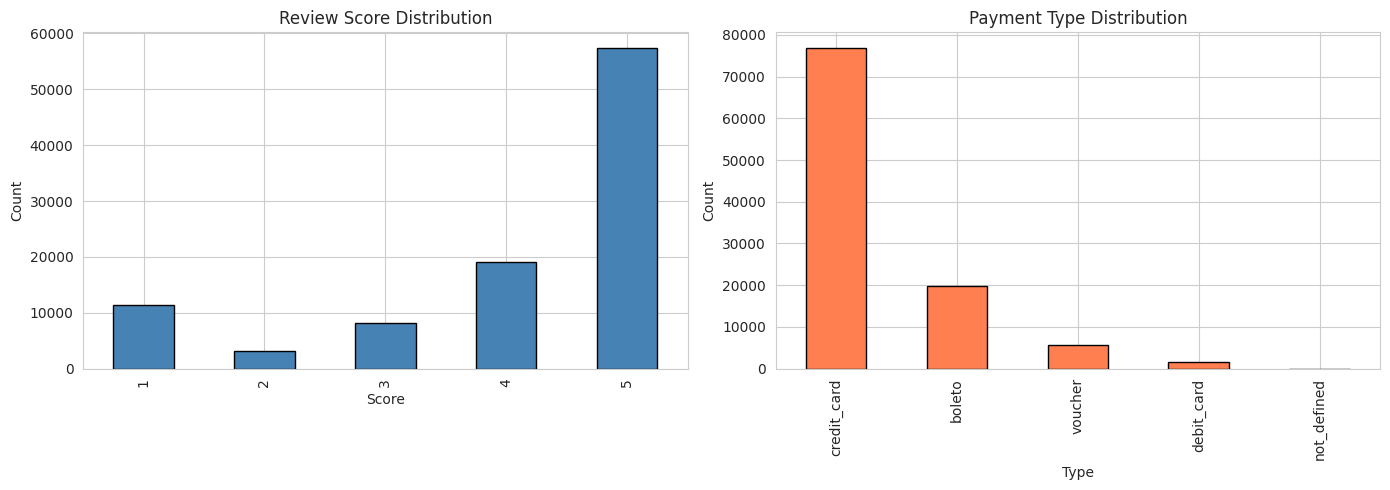

In [ ]:
# Review Scores & Payments

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data['order_reviews']['review_score'].value_counts().sort_index().plot.bar(
    ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Review Score Distribution')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')

data['order_payments']['payment_type'].value_counts().plot.bar(
    ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Payment Type Distribution')
axes[1].set_xlabel('Type'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()